# Load Import

### 🔧 1. Setup and Library Imports
We configure the environment to access our core logic in the `src/` directory and import essential data science libraries. We also include custom visualization and evaluation utilities built for this project.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import load_data, preprocess_data
from src.kmeans import train_kmeans, evaluate_kmeans
from src.random_forest_model import train_random_forest, get_feature_importances
from src.neural_network import build_neural_network, train_neural_network
from src.evaluation import evaluate_model
from src.visualization import plot_heatmap, plot_feature_importance, plot_model_performance, plot_top_correlations, plot_class_distribution
import tensorflow as tf

import kagglehub
import shutil
import joblib
import warnings
warnings.filterwarnings('ignore')

/Volumes/T7/Coding/Projects BIT/DAI/Financial Security/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 📂 2. Data Acquisition
The **Credit Card Fraud Detection** dataset is sourced via `kagglehub`. We automate the download and organization of the raw CSV file into our local `data/` directory to ensure reproducibility.


In [2]:
# Download latest version
path = kagglehub.dataset_download("jacklizhi/creditcard")
print("Downloaded to:", path)

# Copy all files to the project's data/ directory
data_dir = os.path.abspath('../data')
os.makedirs(data_dir, exist_ok=True)

for file in os.listdir(path):
    src = os.path.join(path, file)
    dst = os.path.join(data_dir, file)
    if os.path.isfile(src):
        shutil.copy2(src, dst)
        print(f"Copied: {file} -> {data_dir}")

print("Done! Files stored in:", data_dir)


Downloaded to: /Users/amaylugun/.cache/kagglehub/datasets/jacklizhi/creditcard/versions/1
Copied: creditcard.csv -> /Volumes/T7/Coding/Projects BIT/DAI/Financial Security/data
Done! Files stored in: /Volumes/T7/Coding/Projects BIT/DAI/Financial Security/data


### 🔍 3. Initial Data Inspection
Fraud detection is a "needle in a haystack" problem. Here, we load the data and verify the class distribution. Fraud typically represents less than 0.2% of the total transactions.


In [2]:
df = load_data('../data/creditcard.csv')
df.head()

df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

### 📊 4. Exploratory Data Analysis (EDA)
Because the features `V1-V28` are PCA-transformed, a standard heatmap shows little correlation between them. We use targeted bar charts to find features that correlate specifically with the `Class` (Fraud) variable and visualize their density distributions.


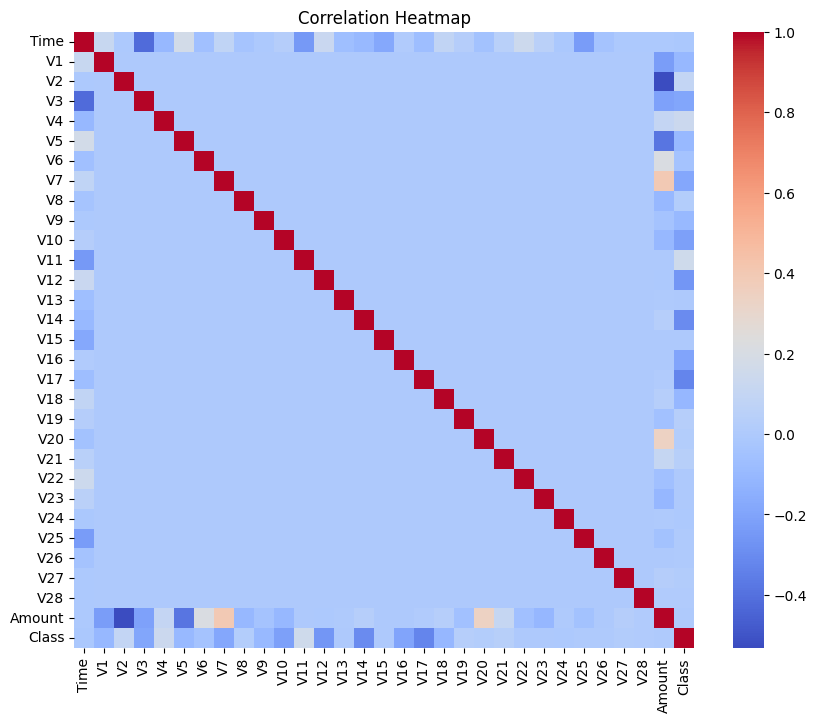

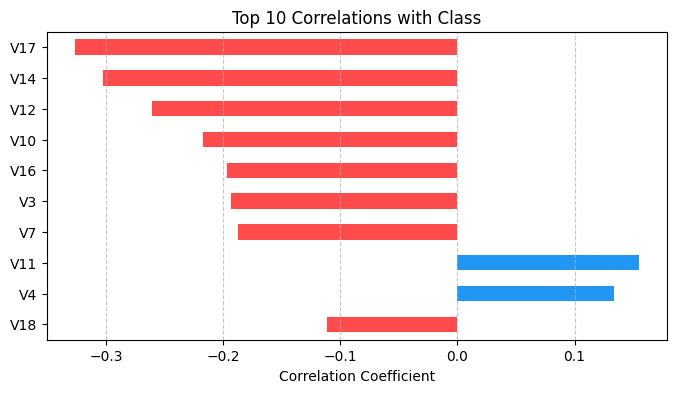

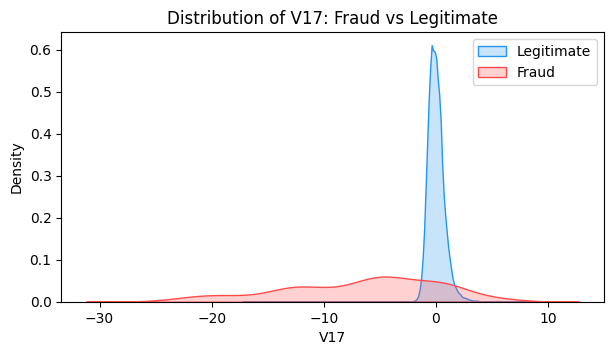

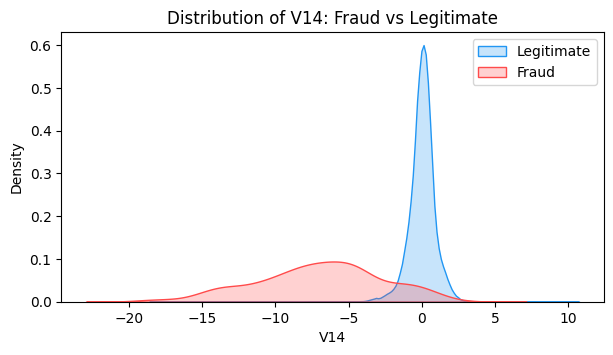

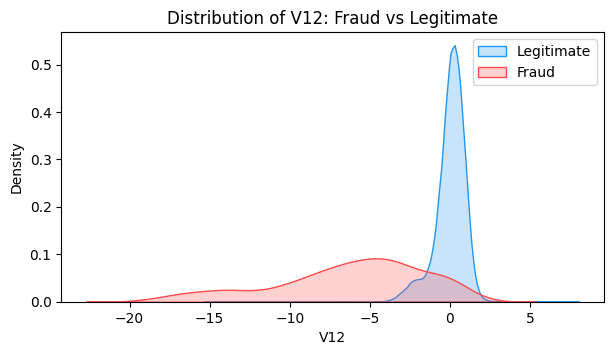

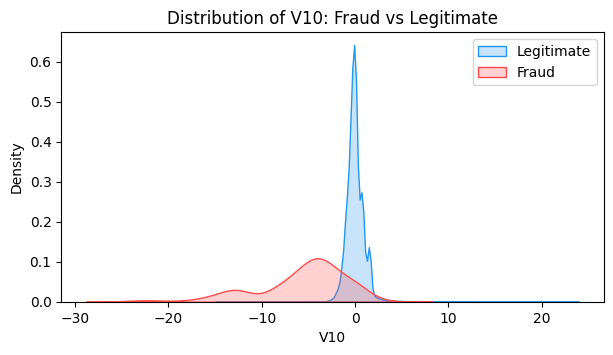

In [4]:
fig = plot_heatmap(df)
plt.show()


fig_corr = plot_top_correlations(df)
plt.show()

for feature in ['V17', 'V14', 'V12', 'V10']:
    fig_dist = plot_class_distribution(df, feature)
    plt.show()

### ⚙️ 5. Preprocessing & SMOTE
To prevent the model from simply guessing "Legitimate" every time, we:
1. **Scale** the `Amount` and `Time` features.
2. **Split** into training and testing sets.
3. Apply **SMOTE** (Synthetic Minority Over-sampling Technique) to create a balanced training set.


In [15]:
X_train, X_test, y_train, y_test, scaler = preprocess_data(df, use_smote=True)

### 📍 6. Anomaly Detection via K-Means
In a real-world scenario, new fraud types emerge constantly. We use unsupervised clustering to see if fraudulent transactions naturally group together, providing a second layer of defense.


In [9]:
kmeans_model, clusters = train_kmeans(X_train)
kmeans_result = evaluate_kmeans(y_train, clusters)
print(kmeans_result)

Cluster       0      1
Actual                
0        227424     27
1        147292  80159


### 🌲 7. Random Forest Classifier
Random Forest is excellent for capturing non-linear interactions. We train the model and inspect **Feature Importance** to see which variables are the strongest indicators of fraud.


In [ ]:
# Train on the training data
rf_model = train_random_forest(X_train, y_train)

# Predict probabilities and classes
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = rf_model.predict(X_test)

# Evaluate using unified module
rf_results = evaluate_model(y_test, y_pred_rf, y_prob=y_prob_rf)

print("Recall (RF) : ", rf_results['recall'])
print("Confusion Matrix (RF): \n", rf_results['confusion_matrix'])
print("AUC-ROC (RF): ", rf_results.get('auc_roc', 'N/A'))

Recall (RF) :  0.826530612244898
Confusion Matrix (RF): 
 [[56852    12]
 [   17    81]]
AUC-ROC (RF):  0.9684455679429904


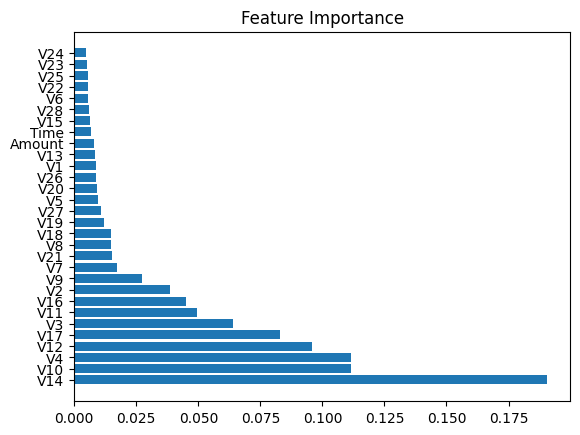

In [7]:
importances = get_feature_importances(rf_model)

fig = plot_feature_importance(importances, df.drop('Class', axis=1).columns)
plt.show()

### 🧠 8. Deep Neural Network (ANN)
We implement a Keras-based Neural Network to capture complex patterns. By training on SMOTE-augmented data, the network learns to distinguish subtle fraud signatures that simpler models might miss.


In [12]:
nn_model = build_neural_network(X_train.shape[1])
nn_model.summary()
nn_model = train_neural_network(nn_model, X_train, y_train, epochs=10)

# Predict probabilities and classes
y_prob_nn = nn_model.predict(X_test).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)

# Evaluate using unified module
nn_results = evaluate_model(y_test, y_pred_nn, y_prob=y_prob_nn)

print("Recall (NN) :", nn_results['recall'])
print("Confusion Matrix (NN) :\n", nn_results['confusion_matrix'])
print("AUC-ROC (NN): ", nn_results.get('auc_roc', 'N/A'))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 12s 849us/step - Recall: 0.9661 - loss: 0.0674 - val_Recall: 0.9975 - val_loss: 0.0170
Epoch 2/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 11s 926us/step - Recall: 0.9910 - loss: 0.0297 - val_Recall: 0.9998 - val_loss: 0.0106
Epoch 3/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 819us/step - Recall: 0.9933 - loss: 0.0236 - val_Recall: 0.9983 - val_loss: 0.0136
Epoch 4/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 792us/step - Recall: 0.9951 - loss: 0.0194 - val_Recall: 1.0000 - val_loss: 0.0039
Epoch 5/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 725us/step - Recall: 0.9956 - loss: 0.0177 - val_Recall: 0.9993 - val_loss: 0.0111
Epoch 6/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 714us/step - Recall: 0.9963 - loss: 0.0163 - val_Recall: 0.9994 - val_loss: 0.0106
Epoch 7/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 8s 727us/step - Recall: 0.9968 - loss: 0.0149 - val_Recall: 0.9986 - val_loss: 0.0071
Epoch 8/10
11373/11373 ━━━━━━━━━━━━━━━━━━━━ 9s 774us/step - Recall: 0.9970 - loss: 0.014

### 9. Save the trained models

In [9]:
os.makedirs("../models", exist_ok=True)
joblib.dump(rf_model, "../models/rf_model.pkl")
nn_model.save("../models/nn_model.keras")

### Load Pretrained models

In [10]:
rf = joblib.load('../models/rf_model.pkl')
nn = tf.keras.models.load_model('../models/nn_model.keras')

### Evaluation Plots
Visualizing the performance using side-by-side matrices and curves.

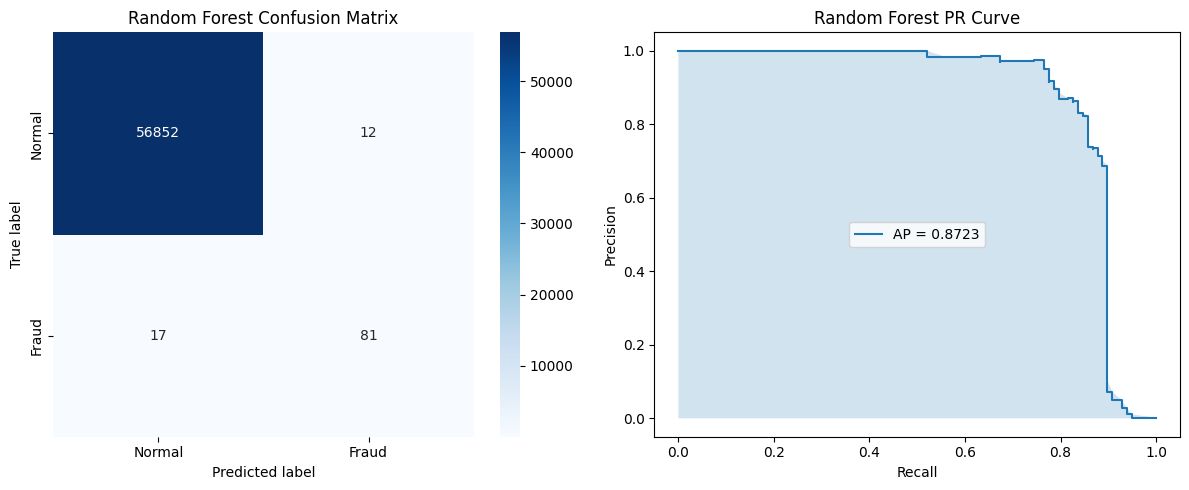

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 342us/step


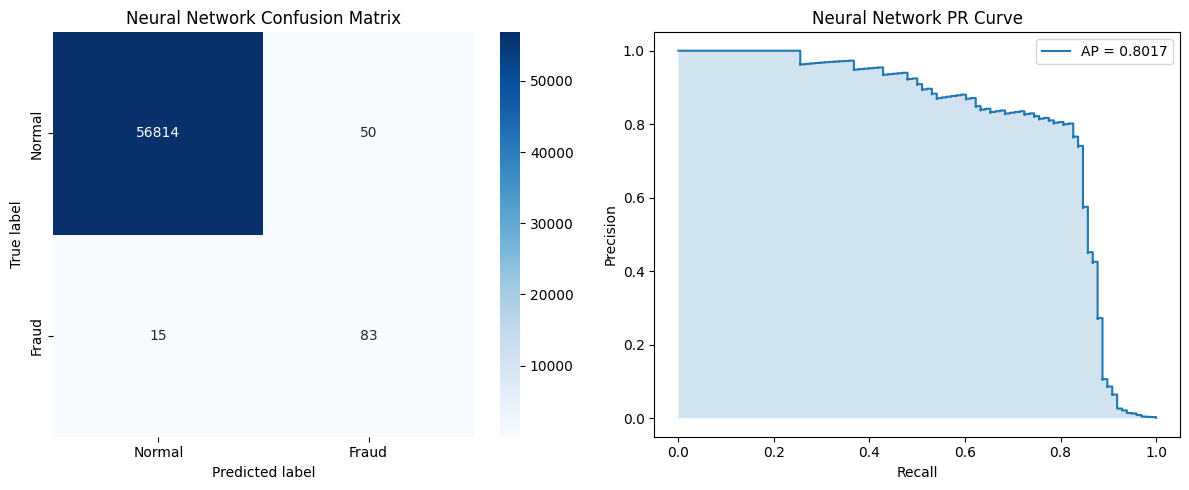

In [11]:
# Visualizing Random Forest results
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
plot_model_performance(y_test, y_prob_rf, title_suffix='Random Forest')
plt.show()

# Visualizing Neural Network results
y_prob_nn = nn_model.predict(X_test).flatten()
plot_model_performance(y_test, y_prob_nn, title_suffix='Neural Network')
plt.show()